<a href="https://colab.research.google.com/github/mohamadfaisalbashir/scikit-learn-cookbook/blob/main/06_Advanced_Logistic_Regression_and_Extensions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Advanced Logistic Regression and Extensions**

This notebook covers Advanced Logistic Regression and Extensions:

1. Overview of Logistic Regression
2. Multiclass Classification Techniques
3. Regularization in Logistic Regression
4. Multilabel Classification Concepts
5. Model Evaluation Metrics

# **1. Overview of Logistic Regression**

While linear regression predicts continuous values, **logistic regression** predicts the *probability* that an input belongs to a particular class. It does so by applying the **sigmoid (logistic) function** to a linear combination of input features, squashing the output to the range [0, 1].

## **1.1 Mathematical Foundation**

$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n)}}$$

- The output is a probability between 0 and 1  
- A threshold (typically 0.5) converts the probability into a class prediction  
- Coefficients are estimated via **Maximum Likelihood Estimation (MLE)**

## **1.2 Log-Odds and Decision Boundary**

Logistic regression models the **log-odds** (logit) of the probability as a linear function. The decision boundary is linear in terms of log-odds, making it effective for linearly separable classification problems.

## **1.3 Key Evaluation Metrics**

| Metric | Description |
|---|---|
| **Accuracy** | Proportion of correctly classified instances |
| **Precision** | Of all predicted positives, how many were truly positive |
| **Recall** | Of all actual positives, how many were predicted positive |
| **F1-Score** | Harmonic mean of precision and recall |
| **Confusion Matrix** | Table of TP, TN, FP, FN counts |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df[data.feature_names], df['target'],
    test_size=0.2, random_state=2024
)

print(f"Dataset shape : {df.shape}")
print(f"Classes       : {data.target_names}")
print(f"Class balance : {np.bincount(y)}")


Dataset shape : (569, 31)
Classes       : ['malignant' 'benign']
Class balance : [212 357]


Accuracy: 0.95


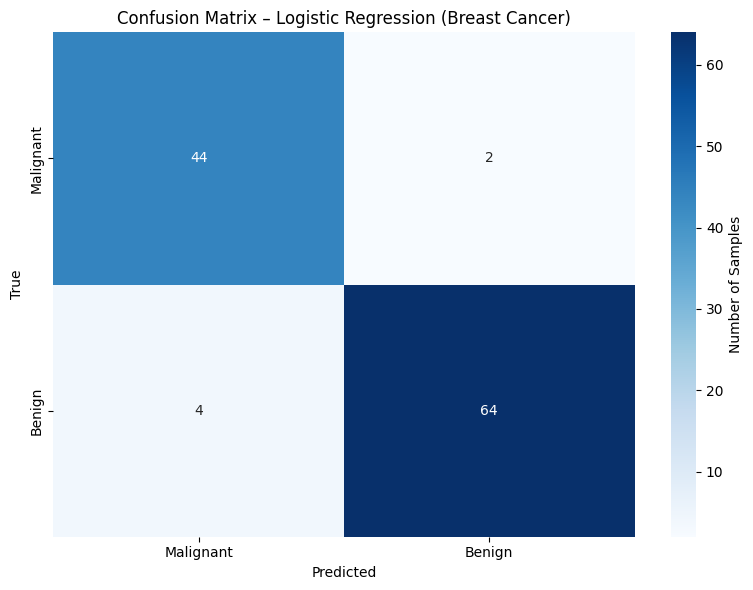

Accuracy: 0.95


Classification Report:


,precision,recall,f1-score,support
Malignant,0.917,0.957,0.936,46
Benign,0.970,0.941,0.955,68
accuracy,0.947,0.947,0.947,1
macro avg,0.943,0.949,0.946,114
weighted avg,0.948,0.947,0.948,114


In [2]:
# Fit logistic regression
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion matrix
class_names = ['Malignant', 'Benign']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Logistic Regression (Breast Cancer)')
plt.tight_layout()
plt.show()

# Classification report
report_df = pd.DataFrame(
    classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
).transpose()

styled_df = (report_df
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
'f1-score': '{:.3f}',
'support': '{:.0f}'
})
)
print(f'Accuracy: {accuracy:.2f}\n')
print("\nClassification Report:")
display(styled_df)


# **2. Multiclass Classification Techniques**

Binary logistic regression assigns observations to one of two classes. When the outcome has **three or more classes**, we need one of two multiclass extensions:

## **2.1 One-vs-Rest (OvR)**

- Trains a separate binary classifier for each class  
- Each classifier distinguishes its class from all others  
- The class with the highest confidence score wins the prediction  
- Works with the `liblinear` solver in scikit-learn

## **2.2 Multinomial Logistic Regression (Softmax)**

- Models all classes simultaneously using the **SoftMax function**  
- Estimates multiple coefficient vectors (one per class) and optimizes them jointly  
- More appropriate when classes are mutually exclusive  
- Uses lbfgs or newton-cg solvers

## **2.3 Solver Compatibility**

| Solver | OvR | Multinomial | Notes |
|---|---|---|---|
| liblinear | ✅ | ❌ | Fast for small datasets |
| lbfgs | ✅ | ✅ | Default; good general-purpose solver |
| saga | ✅ | ✅ | Best for large datasets |

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report)
from sklearn.inspection import DecisionBoundaryDisplay
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

ovr_model = LogisticRegression(solver='liblinear')
ovr_model.fit(X_train, y_train)

multinomial_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs', max_iter = 1000
)
multinomial_model.fit(X_train, y_train)

y_pred_ovr = ovr_model.predict(X_test)
y_pred_multinomial = multinomial_model.predict(X_test)

accuracy_ovr = accuracy_score(y_test, y_pred_ovr)
report_ovr = pd.DataFrame(classification_report(
    y_test, y_pred_ovr, output_dict=True)).transpose()
print("One-vs-Rest (OvR) Logistic Regression:")
styled_ovr = (report_ovr
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_ovr)

accuracy_multinomial = accuracy_score(y_test, y_pred_multinomial)
report_multinomial = pd.DataFrame(classification_report(
    y_test, y_pred_multinomial,
    output_dict=True)).transpose()
print("Multinomial Logistic Regression:")
styled_multinomial = (report_multinomial
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
    })
)
display(styled_multinomial)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


One-vs-Rest (OvR) Logistic Regression:


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.917,0.917,0.917,12
2,0.933,0.933,0.933,15
accuracy,0.956,0.956,0.956,1
macro avg,0.950,0.950,0.950,45
weighted avg,0.956,0.956,0.956,45


Multinomial Logistic Regression:


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.846,0.917,0.880,12
2,0.929,0.867,0.897,15
accuracy,0.933,0.933,0.933,1
macro avg,0.925,0.928,0.926,45
weighted avg,0.935,0.933,0.934,45


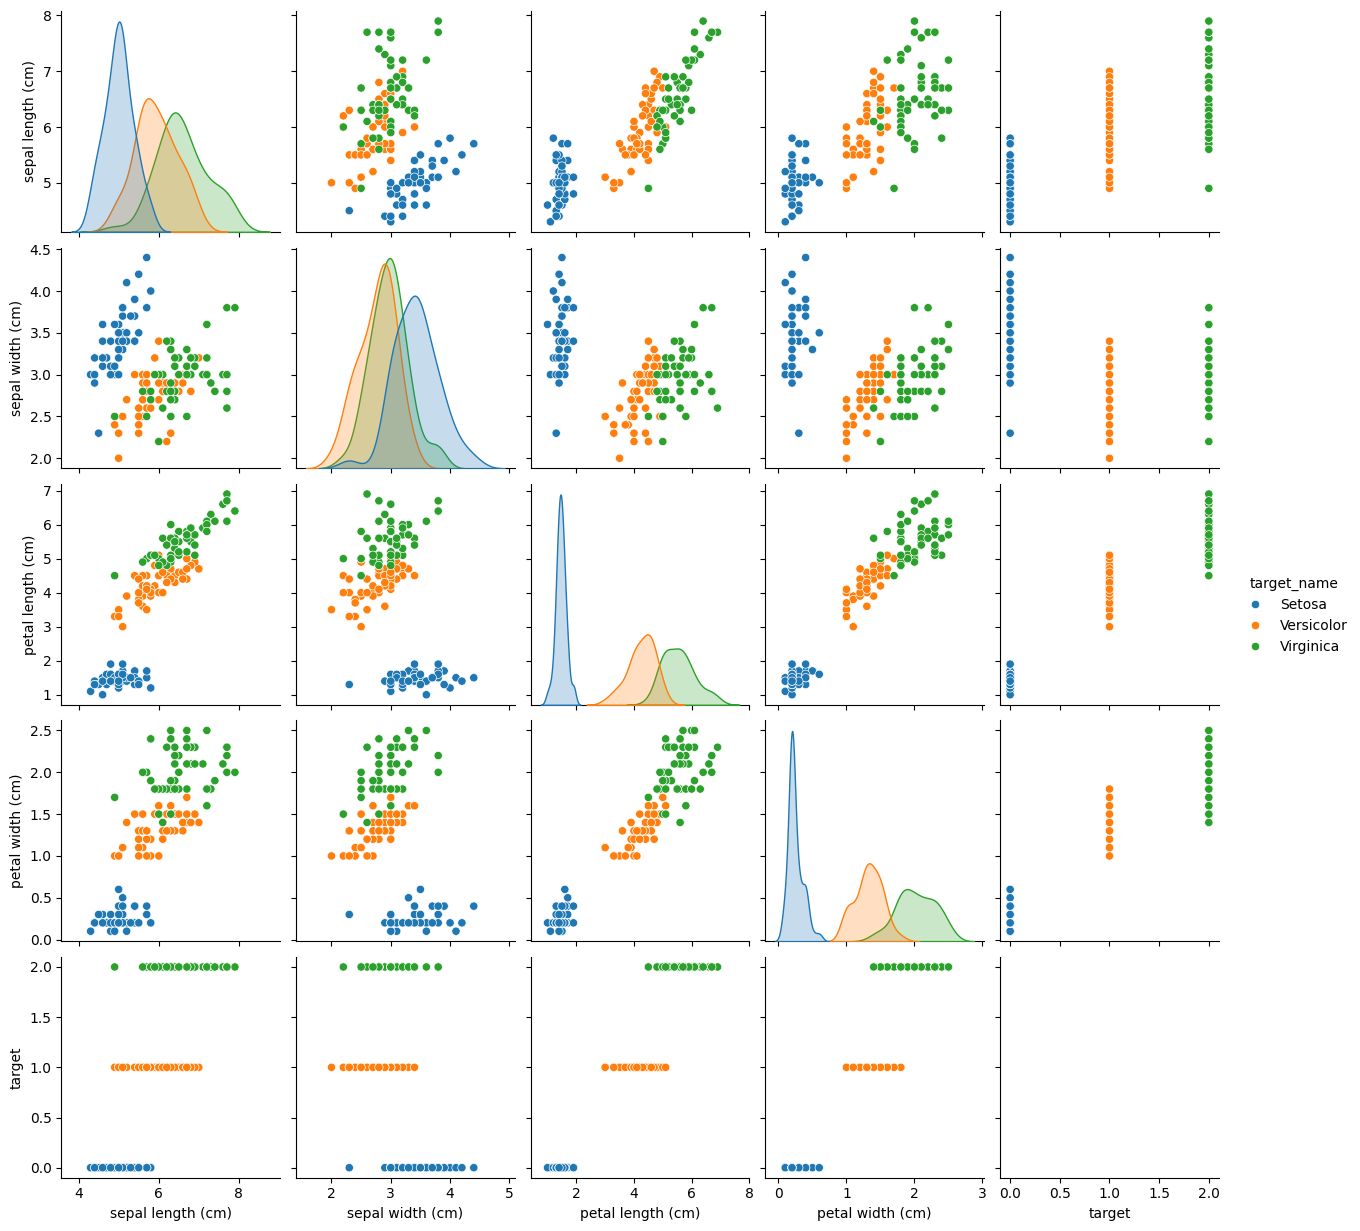

In [4]:
target_names = {0: 'Setosa',
                1: 'Versicolor',
                2: 'Virginica'}
df['target_name'] = df['target'].map(target_names)
sns.pairplot(df, hue='target_name', diag_kind='kde')
plt.show()

# **3. Regularization in Logistic Regression**

Just as with linear regression, logistic regression can overfit on high-dimensional or noisy data. **Regularization** adds a penalty term to the loss function to constrain the coefficient magnitudes.

## **3.1 The C Parameter**

In scikit-learn's `LogisticRegression`, regularization is controlled by **C — the inverse of regularization strength**:

$$C = \frac{1}{\lambda}$$

- **Small C** → strong regularization → more shrinkage → simpler model  
- **Large C** → weak regularization → coefficients can grow freely → more complex model

## **3.2 Ridge vs. Lasso in Logistic Regression**

| Penalty | Effect | Best When |
|---|---|---|
| L2 (Ridge, `penalty='l2'`) | Shrinks all coefficients toward zero | All features may be relevant |
| L1 (Lasso, `penalty='l1'`) | Drives some coefficients to exactly zero | Many irrelevant features suspected |

**Note:** Not all solvers support all penalties. `liblinear` supports both L1 and L2. For large datasets, use `saga`.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report)
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2024)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ridge_model = LogisticRegression(penalty='l2', solver='liblinear', C=0.1)
ridge_model.fit(X_train, y_train)

lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1)
lasso_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
report_ridge = pd.DataFrame(classification_report(
    y_test, y_pred_ridge, output_dict=True)).transpose()
print("Ridge (L2) Regularized Logistic Regression:")
styled_ridge = (report_ridge
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_ridge)

accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
report_lasso = pd.DataFrame(classification_report(
    y_test, y_pred_lasso, output_dict=True)).transpose()
print("Lasso (L1) Regularized Logistic Regression:")
styled_lasso = (report_lasso
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_lasso)

Ridge (L2) Regularized Logistic Regression:


,precision,recall,f1-score,support
0,0.985,0.970,0.977,67
1,0.981,0.990,0.986,104
accuracy,0.982,0.982,0.982,1
macro avg,0.983,0.980,0.982,171
weighted avg,0.982,0.982,0.982,171


Lasso (L1) Regularized Logistic Regression:


,precision,recall,f1-score,support
0,0.930,0.985,0.957,67
1,0.990,0.952,0.971,104
accuracy,0.965,0.965,0.965,1
macro avg,0.960,0.968,0.964,171
weighted avg,0.966,0.965,0.965,171


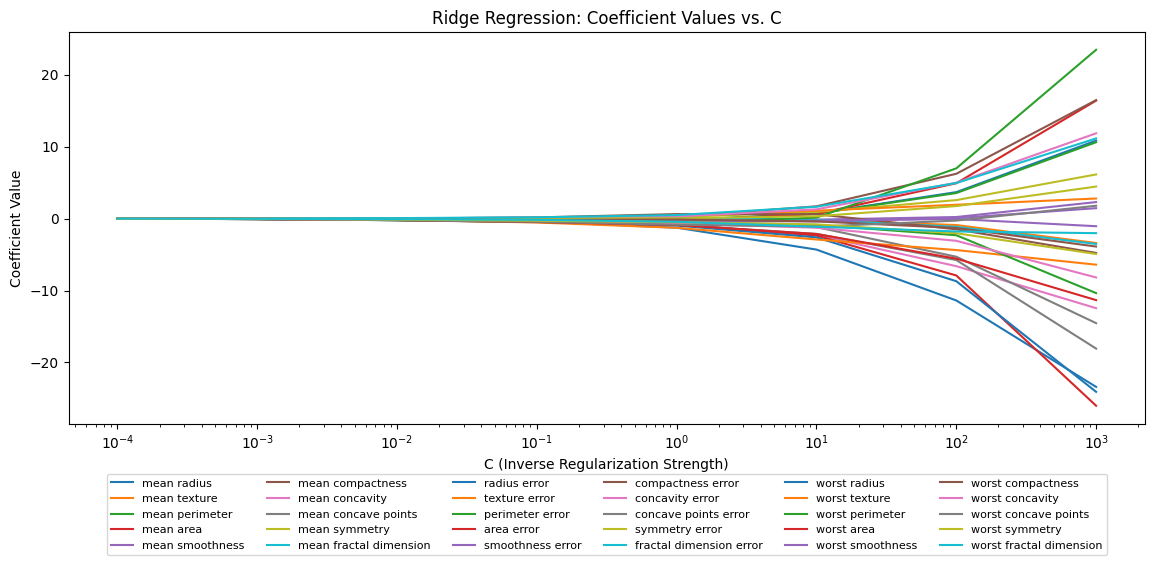

In [6]:
C_values = np.array([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])
coefs_ridge = []
for C in C_values:
    ridge_model = LogisticRegression(penalty='l2', solver='liblinear', C=C)
    ridge_model.fit(X_train, y_train)
    coefs_ridge.append(ridge_model.coef_[0])
plt.figure(figsize=(12, 6))
for i in range(X.shape[1]):
    plt.plot(
        C_values, [coef[i] for coef in coefs_ridge],
        label=feature_names[i]
)
plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: Coefficient Values vs. C')
plt.legend(
    bbox_to_anchor=(0.5, -0.35),
    ncol=6, loc='lower center', fontsize=8
)
plt.tight_layout()
plt.show()

# **4. Multilabel Classification**

In standard classification, each observation belongs to exactly one class. **Multilabel classification** allows each observation to be associated with *multiple* class labels simultaneously — common in text tagging, image annotation, and bioinformatics.

## **4.1 Approach: Per-Label Binary Models**

The simplest strategy trains an independent logistic regression model for each label. At prediction time, each model independently determines whether its label applies:

```
For each label i in {0, 1, ..., n_labels}:
    Fit: LogisticRegression().fit(X_train, y_train[:, i])
    Predict: y_pred[:, i] = model.predict(X_test)
```

## **4.2 Shortcut: MultiOutputClassifier**

scikit-learn provides `MultiOutputClassifier()` as a wrapper that automates this process, accepting any base classifier as input.

## **4.3 Evaluation**

- Standard accuracy requires **exact match** across all labels — strict  
- Per-label precision, recall, and F1-score provide more granular insight  
- Co-occurrence analysis reveals which label combinations are most frequent

In [7]:
from sklearn.datasets import make_multilabel_classification

# Synthetic multilabel dataset: 5 classes, up to 2 labels per sample
X_ml, y_ml = make_multilabel_classification(
    n_samples=1000, n_features=20,
    n_classes=5, n_labels=2, random_state=2024
)

X_tr_ml, X_te_ml, y_tr_ml, y_te_ml = train_test_split(
    X_ml, y_ml, test_size=0.3, random_state=2024
)

# Train one binary classifier per label
models_ml = []
y_pred_all = []

for i in range(y_tr_ml.shape[1]):
    m = LogisticRegression(solver='liblinear')
    m.fit(X_tr_ml, y_tr_ml[:, i])
    models_ml.append(m)
    y_pred_all.append(m.predict(X_te_ml))

y_pred_ml = np.array(y_pred_all).T

# Evaluate
acc_ml = accuracy_score(y_te_ml, y_pred_ml)
print(f"Exact-match Accuracy: {acc_ml:.4f}")

print("\nPer-label Classification Report:")
report_ml = pd.DataFrame(
    classification_report(y_te_ml, y_pred_ml, zero_division=1, output_dict=True)
).transpose()
print(report_ml.round(3).to_string())


Exact-match Accuracy: 0.3400

Per-label Classification Report:
              precision  recall  f1-score  support
0                 0.808   0.813     0.811    166.0
1                 0.801   0.845     0.823    181.0
2                 0.674   0.333     0.446     93.0
3                 0.750   0.176     0.286     34.0
4                 0.575   0.477     0.522     88.0
micro avg         0.757   0.653     0.701    562.0
macro avg         0.722   0.529     0.577    562.0
weighted avg      0.744   0.653     0.677    562.0
samples avg       0.787   0.782     0.680    562.0


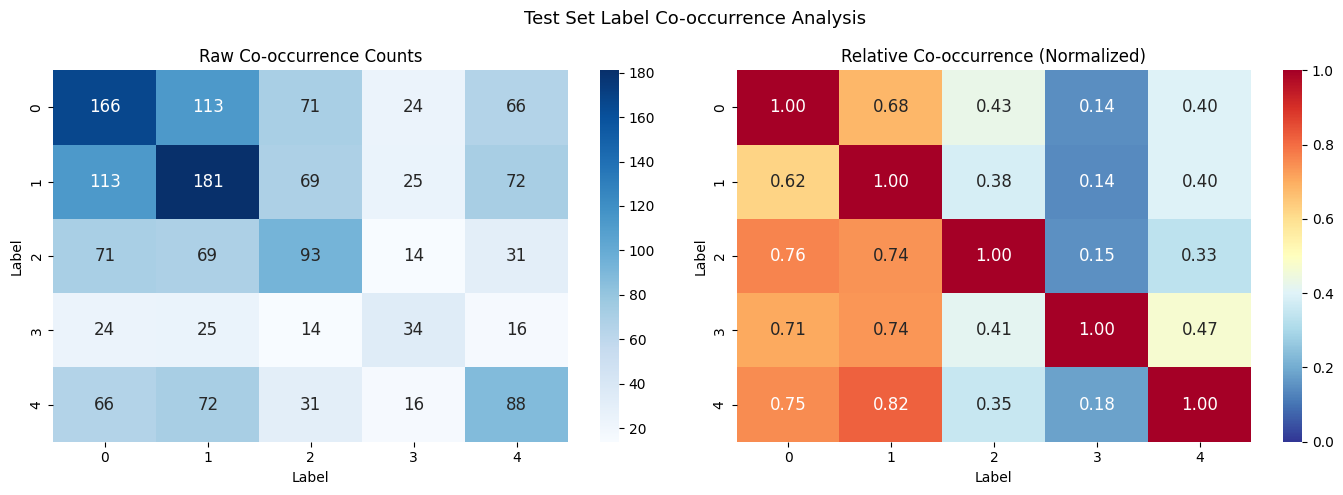

Label Frequencies (test set):
  Label 0: 166 samples (55.3%)
  Label 1: 181 samples (60.3%)
  Label 2: 93 samples (31.0%)
  Label 3: 34 samples (11.3%)
  Label 4: 88 samples (29.3%)


In [8]:
# Label co-occurrence heatmap
cooccurrence = y_te_ml.T @ y_te_ml
diag = np.diag(cooccurrence)
relative_cooc = cooccurrence / diag[:, None]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='Blues', ax=ax1, annot_kws={"fontsize":12})
ax1.set_title('Raw Co-occurrence Counts')
ax1.set_xlabel('Label'); ax1.set_ylabel('Label')

sns.heatmap(relative_cooc, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax2,
            vmin=0, vmax=1, annot_kws={"fontsize":12})
ax2.set_title('Relative Co-occurrence (Normalized)')
ax2.set_xlabel('Label'); ax2.set_ylabel('Label')

plt.suptitle('Test Set Label Co-occurrence Analysis', fontsize=13)
plt.tight_layout()
plt.show()

# Label frequencies
print("Label Frequencies (test set):")
for i in range(y_te_ml.shape[1]):
    count = y_te_ml[:, i].sum()
    print(f"  Label {i}: {count} samples ({count/len(y_te_ml)*100:.1f}%)")


# **5. Model Evaluation Metrics**

For classification models, accuracy alone is often insufficient — especially in **imbalanced** or **high-stakes** settings (e.g., medical diagnosis). This section consolidates the key metrics introduced throughout the chapter.

## **5.1 Core Metrics**

| Metric | Formula | Use Case |
|---|---|---|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | Balanced classes |
| **Precision** | $\frac{TP}{TP+FP}$ | When false positives are costly |
| **Recall** | $\frac{TP}{TP+FN}$ | When false negatives are costly |
| **F1-Score** | $\frac{2 \cdot P \cdot R}{P + R}$ | Balanced precision-recall trade-off |

## **5.2 ROC Curve and AUC**

The **ROC (Receiver Operating Characteristic) curve** plots the True Positive Rate against the False Positive Rate across all decision thresholds. The **AUC (Area Under the Curve)** summarizes this into a single value:

- AUC = 1.0 → perfect classifier  
- AUC = 0.5 → no better than random guessing

Accuracy 0.94
Precision 0.94
Recall 0.95
F1 Score 0.95
ROC AUC 0.99
Classification Report
              precision    recall  f1-score   support

           0       0.92      0.91      0.92        67
           1       0.94      0.95      0.95       104

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



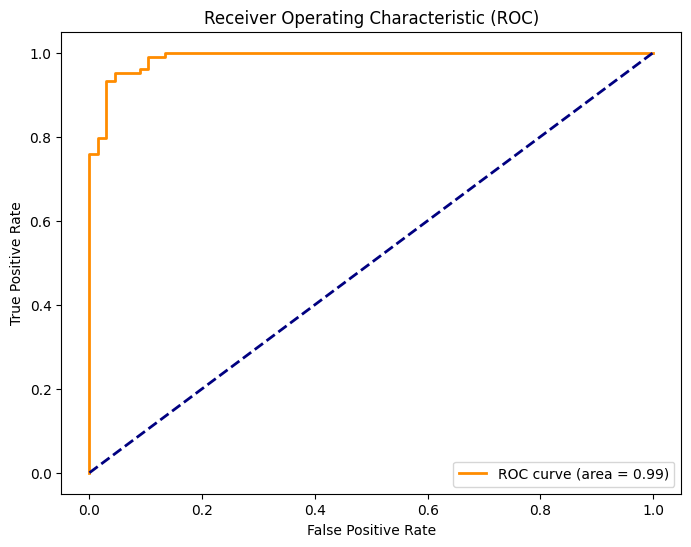

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
    precision_score, recall_score,
    f1_score, roc_curve, auc
)
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

model = LogisticRegression(solver='liblinear')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
report = classification_report(y_test, y_pred)

print(f"Accuracy {accuracy:.2f}")
print(f"Precision {precision:.2f}")
print(f"Recall {recall:.2f}")
print(f"F1 Score {f1:.2f}")
print(f"ROC AUC {roc_auc:.2f}")
print("Classification Report")
print(report)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy',
         lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()